# Analysis Results

## 1D-Ising Chain

### $\tau$ hyperparameter

#### F-CRAB case

##### Data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

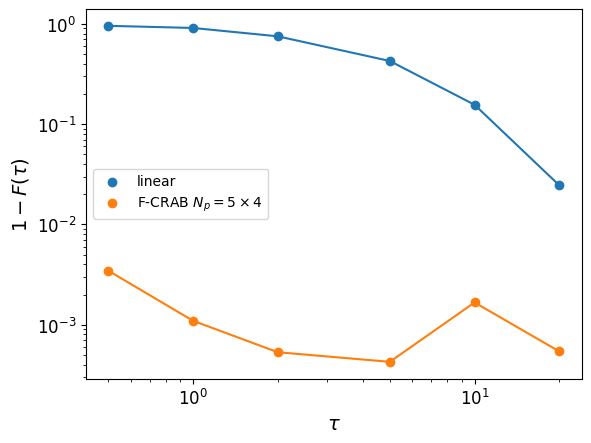

In [2]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"F-CRAB $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-0.8804029447625693, -1.4260674555887938, -2.00640010125504, -2.5720786050168725, -2.791375093967228, -2.9704987988783955, -3.2795727951482467, -3.573310746926034, -3.823885668825562, -4.373527794993027, -4.648266129693926, -4.919184150662309, -5.001863251737222, -5.069364099694924, -5.2127282580091805, -5.354302258685687, -5.481913616785891, -5.584867129468939, -5.670071997190844, -5.679783114678931, -5.6903557814840315, -5.719396473765049, -5.737683634332196, -5.760826693395265, -5.780143630824945, -5.803362367883634, -5.83347368658336, -5.8706607761073775, -5.896472758878025, -5.919290372187072, -5.923992965701516, -5.936296236945005, -5.941595774166529, -5.953346119267187, -5.961332724468282, -5.968676241591428, -5.972000321430145, -5.97252802201323, -5.972870057663839, -5.974608492092237, -5.976490634697706, -5.979674869428492, -5.980951667175825, -5.981623787631165, -5.982028197749256, -5.982308705360454, -5.9834052938811615, -5.984306955688536, -5.9845229711612005, -5.984696977

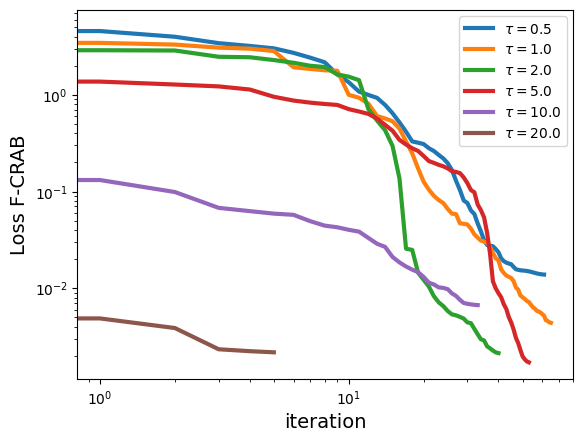

In [6]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss F-CRAB", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

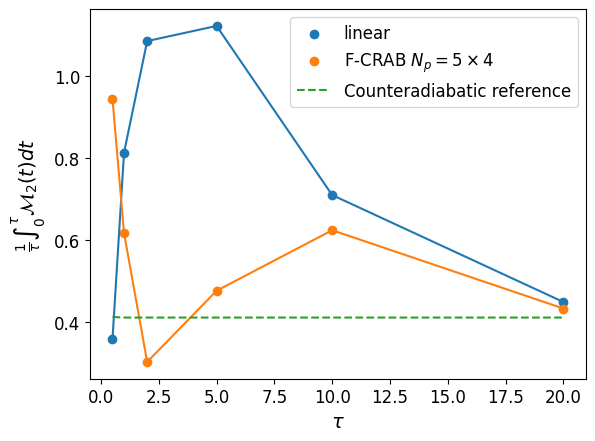

In [23]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

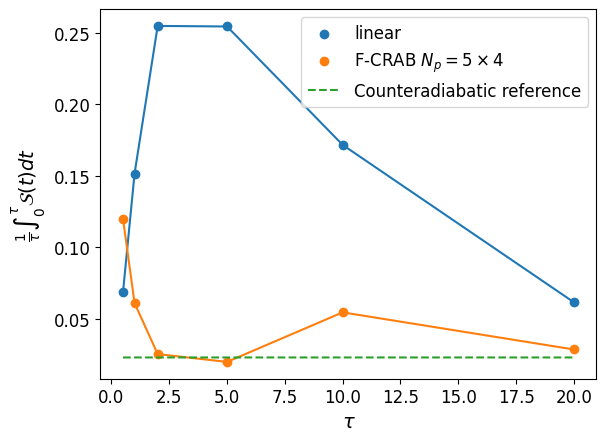

In [7]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

#### SoftPlus + Fourier case

##### Data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5_positive fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

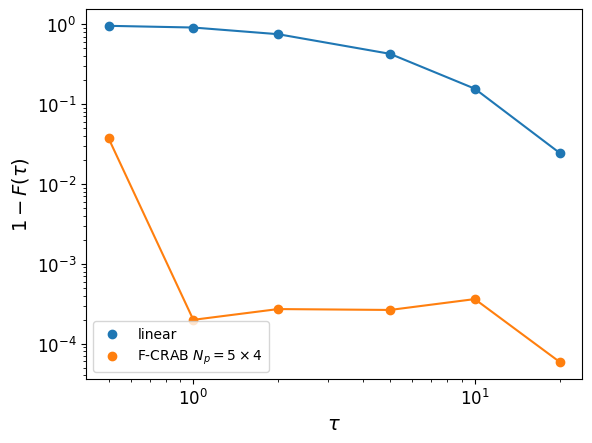

In [2]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"F-CRAB $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-2.8110318032375208, -2.8898391559641743, -2.93493125258016, -3.050618059574512, -3.106940536114735, -3.1733480775223435, -3.2893548378916284, -3.5601059469228686, -4.070826042476574, -4.836932721703132, -5.250133089228747, -5.37488309531815, -5.468856425605605, -5.579660923146513, -5.6766011793538595, -5.719262283199554, -5.741192242198411, -5.778658996196345, -5.820400566676487, -5.834833622542545, -5.839893690412584, -5.842883681924038, -5.844707326753715, -5.845117738015818, -5.845362762579752, -5.8462649090265435, -5.847200489448455, -5.847341187598993, -5.847593743302007, -5.847683521603551, -5.847748724398588, -5.847975349770664, -5.8485050756669805, -5.8489267573276145, -5.849200016872027, -5.849574956480269, -5.8496585445771325, -5.849815754373687]
[-2.8863793591540614, -2.9484377034019214, -3.201578973829773, -3.2495064285622948, -3.5540946673408884, -3.8952313907072376, -4.077946180152375, -4.446918612554835, -5.288268152199236, -5.560888465035385, -5.738973943510565, -5.82

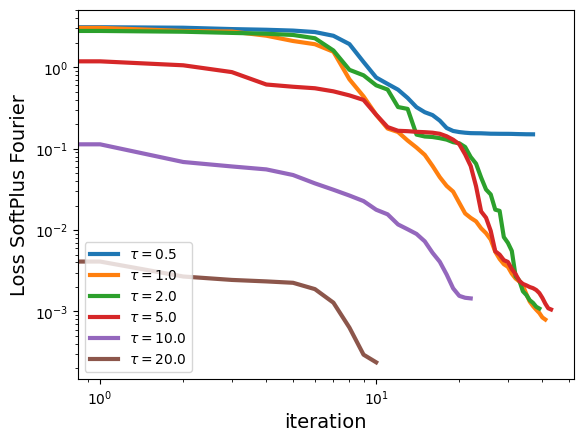

In [3]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss SoftPlus Fourier", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

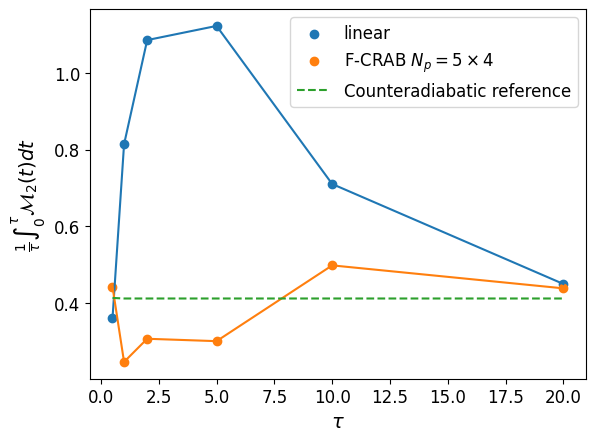

In [4]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

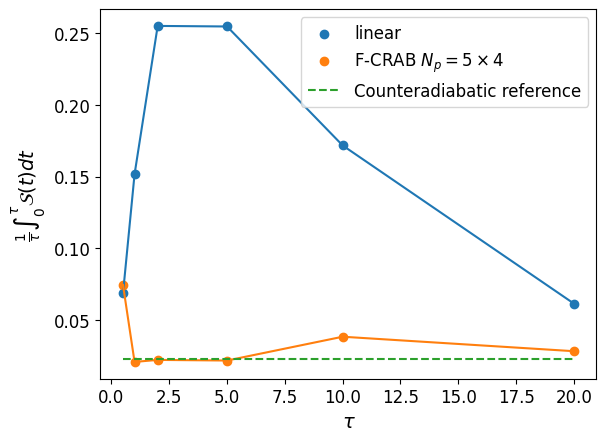

In [5]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

### QUBO